# k-NN — classificação dos estados do jogo da velha

Este experimento utiliza o algoritmo dos **k vizinhos mais próximos** para classificar
os quatro estados do jogo. Compara as duas representações de entrada com os mesmos
conjuntos de treino, validação e teste dos demais classificadores.

In [1]:
import time
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

## 1. Configuração do experimento

Comparamos as mesmas amostras em duas representações: **A1**, com as nove casas numéricas
(`b=0`, `x=1`, `o=-1`), e **A2**, com 15 características derivadas. Nesta última, as posições
ocupadas são nove indicadores binários, um por casa. As demais características são contagens
de X e O, alinhamentos com duas marcas, casas vazias e próximo turno hipotético.
A semente 42 identifica a configuração reproduzível do experimento.

In [2]:
SEED = 42
RAIZ = next(
    (pasta for pasta in [Path.cwd(), *Path.cwd().parents]
     if (pasta / "dataset/processado/abordagem_1/treino.csv").is_file()),
    None,
)
if RAIZ is None:
    raise FileNotFoundError("Execute o notebook dentro da pasta deste projeto.")
BASE = RAIZ / "dataset/processado"

CLASSES = ["Tem jogo", "Jogador X venceu", "Jogador O venceu", "Empate"]
abordagens = {"abordagem_1": "A1 (tabuleiro)", "abordagem_2": "A2 (características)"}

## 2. Leitura dos conjuntos preparados

Carregamos os CSVs de treino, validação e teste, separados fisicamente na preparação dos dados.
`X` contém as características e `y` contém o rótulo `estado`. Excluímos `id_tabuleiro`, que serve
para auditoria, e `estado`, que é a resposta a ser prevista, das entradas do classificador.
As divisões são compartilhadas por todos os algoritmos.

In [3]:
dados = {}
for ab in abordagens:
    d = {}
    for conjunto, sufixo in [("treino", "train"), ("validacao", "val"), ("teste", "test")]:
        df = pd.read_csv(f"{BASE}/{ab}/{conjunto}.csv")
        d[f"ids_{sufixo}"] = df["id_tabuleiro"]
        d[f"y_{sufixo}"] = df["estado"].values
        d[f"X_{sufixo}"] = df.drop(columns=["id_tabuleiro", "estado"])
    dados[ab] = d

for ab in abordagens:
    print(abordagens[ab])
    print("  X_train:", dados[ab]["X_train"].shape, " y_train:", dados[ab]["y_train"].shape)
    print("  X_val:  ", dados[ab]["X_val"].shape, " y_val:  ", dados[ab]["y_val"].shape)
    print("  X_test: ", dados[ab]["X_test"].shape, " y_test: ", dados[ab]["y_test"].shape)

A1 (tabuleiro)
  X_train: (560, 9)  y_train: (560,)
  X_val:   (92, 9)  y_val:   (92,)
  X_test:  (93, 9)  y_test:  (93,)
A2 (características)
  X_train: (560, 15)  y_train: (560,)
  X_val:   (92, 15)  y_val:   (92,)
  X_test:  (93, 15)  y_test:  (93,)


In [4]:
# classes em cada conjunto
d = dados["abordagem_1"]
pd.DataFrame({"treino": pd.Series(d["y_train"]).value_counts(),
              "validacao": pd.Series(d["y_val"]).value_counts(),
              "teste": pd.Series(d["y_test"]).value_counts()})

,treino,validacao,teste
Empate,140,2,3
Jogador O venceu,140,30,30
Jogador X venceu,140,30,30
Tem jogo,140,30,30


In [5]:
# Verificar a disjunção dos IDs para evitar o mesmo tabuleiro no treino e na avaliação.
ids_train, ids_val, ids_test = set(d["ids_train"]), set(d["ids_val"]), set(d["ids_test"])
print("treino x validação:", len(ids_train & ids_val))
print("treino x teste:    ", len(ids_train & ids_test))
print("validação x teste: ", len(ids_val & ids_test))
print("linhas do treino:", len(d["ids_train"]), "- tabuleiros distintos:", len(ids_train),
      "(repetições = empates reamostrados no treino)")

treino x validação: 0
treino x teste:     0
validação x teste:  0
linhas do treino: 560 - tabuleiros distintos: 431 (repetições = empates reamostrados no treino)


## 3. Definir as métricas de classificação

- **Acurácia:** proporção de previsões corretas entre todos os exemplos avaliados.
- **Precisão (precision):** entre as previsões de uma classe, proporção de exemplos que pertencem a ela.
- **Sensibilidade (recall):** entre os exemplos reais de uma classe, proporção reconhecida pelo modelo.
- **F1 (F-measure):** média harmônica entre precisão e recall, calculada por `2 × precisão × recall / (precisão + recall)`.

Para precisão, recall e F1, adotamos a média **macro**: calculamos a métrica separadamente
para cada uma das quatro classes e, depois, sua média aritmética. Cada classe recebe o
mesmo peso, inclusive **Empate**, que possui poucos exemplos. O F1 macro é a média dos
F1 por classe; ele não é calculado a partir das médias de precisão e recall.

Quando a divisão de uma métrica é indefinida, `zero_division=0` atribui zero.
A acurácia é calculada sobre o total de exemplos. A seleção dos parâmetros utiliza
F1 macro de validação, enquanto o teste é reservado à avaliação das configurações selecionadas.

Referência: [definição de F1 e média macro no scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html).

In [6]:
def metricas(y_real, y_pred):
    return {"acc": accuracy_score(y_real, y_pred),
            "precision": precision_score(y_real, y_pred, labels=CLASSES, average="macro", zero_division=0),
            "recall": recall_score(y_real, y_pred, labels=CLASSES, average="macro", zero_division=0),
            "f1_macro": f1_score(y_real, y_pred, labels=CLASSES, average="macro", zero_division=0)}

## 4. Funcionamento do k-NN e parâmetros avaliados

O k-NN classifica um exemplo a partir dos `k` exemplos de treino mais próximos, segundo
uma medida de distância. A classe prevista resulta dos votos desses vizinhos.
É uma forma de **aprendizado baseado em exemplos**: o ajuste armazena os dados e pode
organizar a estrutura de busca; a classificação ocorre quando um novo exemplo é consultado.

- **Número de vizinhos (`n_neighbors`):** valores menores podem tornar a decisão mais sensível a exemplos individuais; valores maiores suavizam a fronteira e podem perder padrões locais.
- **Distância (`metric`):** comparamos a euclidiana, baseada na raiz da soma das diferenças quadráticas, e a de Manhattan, baseada na soma das diferenças absolutas.
- **Pesos dos votos (`weights`):** `uniform` atribui o mesmo peso aos vizinhos; `distance` dá maior peso aos mais próximos.

Na A2, aplicamos `StandardScaler` somente ao treino, dentro do `Pipeline`, para evitar
que características com maior escala dominem a distância. Na A1, mantemos a codificação
original, pois todas as casas possuem a mesma faixa numérica. O custo da busca depende
do número de exemplos, da dimensão e da estrutura utilizada; sua comparação é feita pelas medições.

Referência: [classificação por vizinhos no scikit-learn](https://scikit-learn.org/stable/modules/neighbors.html).

In [7]:
# Grade definida antes da avaliação no teste; a ordem determina o último desempate.
lista_k = [1, 3, 5, 7, 9, 11, 15]               # padrão 5
lista_metrica = ["euclidean", "manhattan"]      # padrão 'minkowski' (p=2 = euclidiana)
lista_pesos = ["uniform", "distance"]           # padrão 'uniform'

print("Combinações por abordagem:", len(lista_k) * len(lista_metrica) * len(lista_pesos))

Combinações por abordagem: 28


In [8]:
def criar_modelo(ab, k, metrica, pesos):
    knn = KNeighborsClassifier(n_neighbors=k, metric=metrica, weights=pesos)
    if ab == "abordagem_2":
        return make_pipeline(StandardScaler(), knn)   # padroniza as características da A2
    return knn

## 5. Seleção dos parâmetros pela validação

Ajustamos cada combinação de parâmetros no conjunto de treino e avaliamos suas previsões
na validação. A seleção prioriza F1 macro de validação; em empate, considera a acurácia.
Se persistir empate, permanece a primeira configuração encontrada na ordem da grade.
Esse último critério é determinístico e não garante a configuração de menor complexidade.
O teste não participa da seleção.

Registramos também o F1 de treino. Uma diferença acentuada em relação à validação pode
indicar **sobreajuste (overfitting)**, isto é, adaptação excessiva aos exemplos de treino.
A diferença deve ser analisada junto com os resultados por classe e as limitações da amostra.

In [9]:
resultados = []   # uma linha para cada combinação testada
melhor = {}       # melhor modelo de cada abordagem (escolhido pela validação)

for ab in abordagens:
    d = dados[ab]
    for k in lista_k:
        for metrica in lista_metrica:
            for pesos in lista_pesos:
                modelo = criar_modelo(ab, k, metrica, pesos)
                modelo.fit(d["X_train"], d["y_train"])
                m_train = metricas(d["y_train"], modelo.predict(d["X_train"]))
                m_val = metricas(d["y_val"], modelo.predict(d["X_val"]))

                resultados.append({"abordagem": abordagens[ab], "k": k, "metrica": metrica, "pesos": pesos,
                                   "f1_treino": m_train["f1_macro"],
                                   "val_acc": m_val["acc"], "val_f1_macro": m_val["f1_macro"]})

                chave = (m_val["f1_macro"], m_val["acc"])
                if ab not in melhor or chave > melhor[ab]["chave"]:
                    melhor[ab] = {"chave": chave, "f1_treino": m_train["f1_macro"], "modelo": modelo,
                                  "params": {"k": k, "metrica": metrica, "pesos": pesos}}

resultados = pd.DataFrame(resultados)
print("Combinações testadas:", len(resultados))

Combinações testadas: 56


In [10]:
# melhor configuração de cada abordagem
for ab in abordagens:
    print(abordagens[ab], "->", melhor[ab]["params"], " F1 validação =", round(melhor[ab]["chave"][0], 3))

A1 (tabuleiro) -> {'k': 7, 'metrica': 'manhattan', 'pesos': 'uniform'}  F1 validação = 0.652
A2 (características) -> {'k': 3, 'metrica': 'manhattan', 'pesos': 'uniform'}  F1 validação = 0.886


In [11]:
# as 5 melhores combinações de cada abordagem (validação)
for ab in abordagens:
    print(abordagens[ab])
    top = resultados[resultados.abordagem == abordagens[ab]].sort_values(["val_f1_macro", "val_acc"], ascending=False)
    display(top.head(5).round(3))

A1 (tabuleiro)


,abordagem,k,metrica,pesos,f1_treino,val_acc,val_f1_macro
14,A1 (tabuleiro),7,manhattan,uniform,0.829,0.717,0.652
15,A1 (tabuleiro),7,manhattan,distance,1.000,0.739,0.632
19,A1 (tabuleiro),9,manhattan,distance,1.000,0.696,0.616
23,A1 (tabuleiro),11,manhattan,distance,1.000,0.685,0.605
10,A1 (tabuleiro),5,manhattan,uniform,0.852,0.707,0.597


A2 (características)


,abordagem,k,metrica,pesos,f1_treino,val_acc,val_f1_macro
34,A2 (características),3,manhattan,uniform,0.948,0.859,0.886
38,A2 (características),5,manhattan,uniform,0.951,0.859,0.886
39,A2 (características),5,manhattan,distance,0.991,0.837,0.869
32,A2 (características),3,euclidean,uniform,0.931,0.837,0.868
35,A2 (características),3,manhattan,distance,0.991,0.826,0.856


## 6. Avaliação no teste e medição do custo

O teste avalia as configurações selecionadas pela validação. Seus resultados não são usados
para reajustar os parâmetros. As 20 repetições de ajuste e previsão servem para medir o tempo
médio; não constituem novos experimentos para selecionar modelos.

O tempo de previsão corresponde ao lote completo de 93 tabuleiros. Os dados já estão nas
representações preparadas; leitura dos CSVs e extração das características não são cronometradas.
A comparação de custos deve considerar hardware, versões e condições de execução.

In [12]:
tabela = []
previsoes = {}

for ab in abordagens:
    d = dados[ab]
    modelo = melhor[ab]["modelo"]
    params = melhor[ab]["params"]

    # custo: tempo de treino e de predição
    t0 = time.perf_counter()
    for _ in range(20):
        criar_modelo(ab, **params).fit(d["X_train"], d["y_train"])
    tempo_treino = (time.perf_counter() - t0) / 20 * 1000
    t0 = time.perf_counter()
    for _ in range(20):
        modelo.predict(d["X_test"])
    tempo_pred = (time.perf_counter() - t0) / 20 * 1000

    # Métricas de teste da configuração selecionada, sem novo ajuste de parâmetros.
    previsoes[ab] = modelo.predict(d["X_test"])
    m = metricas(d["y_test"], previsoes[ab])
    tabela.append({"abordagem": abordagens[ab],
                   "acuracia": m["acc"], "precision": m["precision"], "recall": m["recall"], "f1_macro": m["f1_macro"],
                   "gap_treino_val": melhor[ab]["f1_treino"] - melhor[ab]["chave"][0],
                   "tempo_treino_ms": tempo_treino, "tempo_pred_ms": tempo_pred})

tabela = pd.DataFrame(tabela)
tabela.round(3)

,abordagem,acuracia,precision,recall,f1_macro,gap_treino_val,tempo_treino_ms,tempo_pred_ms
0,A1 (tabuleiro),0.656,0.562,0.508,0.517,0.177,0.74,1.001
1,A2 (características),0.882,0.908,0.908,0.907,0.061,1.37,1.106


## 7. Resultados por classe e matriz de confusão

O relatório apresenta precisão, recall, F1 e suporte, isto é, quantidade de exemplos reais
por classe. As linhas da matriz de confusão representam classes reais e as colunas,
classes previstas. A diagonal reúne os acertos.

Há somente três empates no teste. Por isso, um único erro altera significativamente o recall
dessa classe, e uma pontuação alta deve ser interpretada com essa limitação.

In [13]:
for ab in abordagens:
    print(abordagens[ab])
    print(classification_report(dados[ab]["y_test"], previsoes[ab], labels=CLASSES, zero_division=0))

A1 (tabuleiro)
                  precision    recall  f1-score   support

        Tem jogo       0.83      0.50      0.62        30
Jogador X venceu       0.75      0.60      0.67        30
Jogador O venceu       0.67      0.93      0.78        30
          Empate       0.00      0.00      0.00         3

        accuracy                           0.66        93
       macro avg       0.56      0.51      0.52        93
    weighted avg       0.73      0.66      0.67        93

A2 (características)
                  precision    recall  f1-score   support

        Tem jogo       0.85      0.77      0.81        30
Jogador X venceu       0.81      0.87      0.84        30
Jogador O venceu       0.97      1.00      0.98        30
          Empate       1.00      1.00      1.00         3

        accuracy                           0.88        93
       macro avg       0.91      0.91      0.91        93
    weighted avg       0.88      0.88      0.88        93



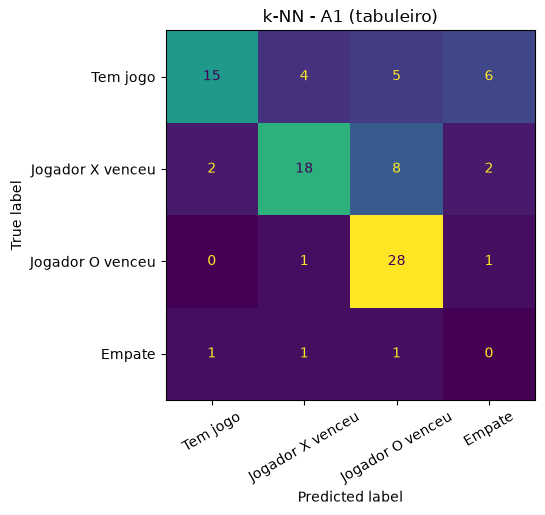

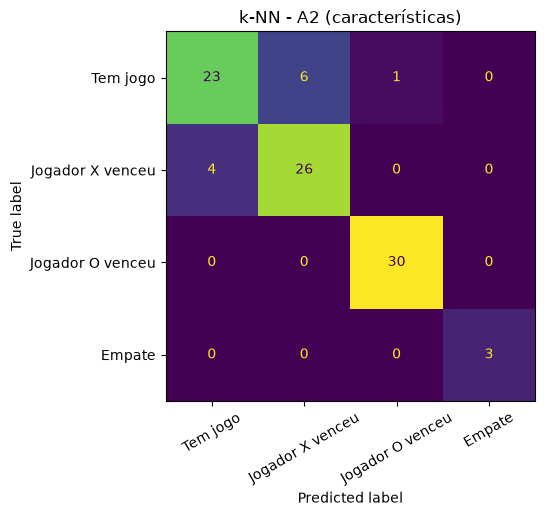

In [14]:
for ab in abordagens:
    resultado = confusion_matrix(dados[ab]["y_test"], previsoes[ab], labels=CLASSES)
    ConfusionMatrixDisplay(resultado, display_labels=CLASSES).plot(xticks_rotation=30, colorbar=False)
    plt.title(f"k-NN - {abordagens[ab]}")
    plt.show()

## 8. Exploração dos resultados em função de k

Para cada `k`, as curvas mostram separadamente o maior F1 de treino e o maior F1 de validação
entre as combinações testadas. Esses máximos podem corresponder a configurações diferentes
de distância ou pesos. Portanto, a distância entre as curvas não deve ser interpretada
como a diferença de generalização de um único modelo.

Para essa análise, utilizamos `gap_treino_val` na tabela final, calculado com as métricas
da mesma configuração selecionada.

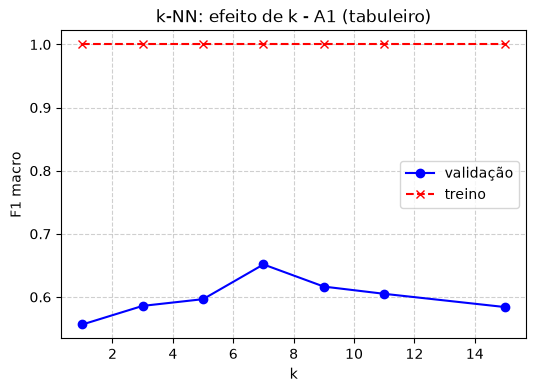

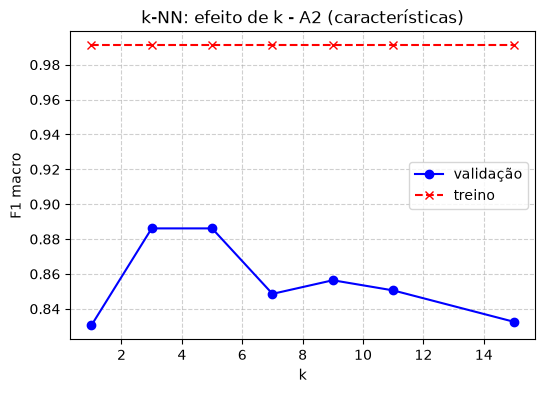

In [15]:
for ab in abordagens:
    s = resultados[resultados.abordagem == abordagens[ab]].groupby("k")[["f1_treino", "val_f1_macro"]].max()
    plt.figure(figsize=(6, 4))
    plt.plot(s.index, s["val_f1_macro"], label="validação", color="blue", marker="o", linestyle="-")
    plt.plot(s.index, s["f1_treino"], label="treino", color="red", marker="x", linestyle="--")
    plt.xlabel("k")
    plt.ylabel("F1 macro")
    plt.title(f"k-NN: efeito de k - {abordagens[ab]}")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.show()

In [16]:
# vizinhos mais próximos de um tabuleiro de teste (A1), para entender a decisão do k-NN
d = dados["abordagem_1"]
knn_a1 = melhor["abordagem_1"]["modelo"]
i = 0
dist, idx = knn_a1.kneighbors(d["X_test"].iloc[[i]])
print("Tabuleiro de teste:", d["ids_test"].iloc[i], "- classe real:", d["y_test"][i], "- previsto:", previsoes["abordagem_1"][i])
print("Vizinhos no treino:")
for dis, j in zip(dist[0], idx[0]):
    print("  ", d["ids_train"].iloc[j], d["y_train"][j], "distância =", round(dis, 2))

Tabuleiro de teste: xooxxbxbo - classe real: Jogador X venceu - previsto: Jogador X venceu
Vizinhos no treino:
   xboxbbxbo Jogador X venceu distância = 2.0
   xboxxbxoo Jogador X venceu distância = 2.0
   xbooxbxbo Tem jogo distância = 3.0
   bboxxoxbo Jogador O venceu distância = 3.0
   xooxbbbxo Tem jogo distância = 3.0
   xboxxobbo Jogador O venceu distância = 3.0
   xooxbxxob Jogador X venceu distância = 4.0


## 9. Comparação das abordagens A1 e A2

A tabela e o gráfico permitem comparar as métricas de teste, a diferença entre treino e
validação da configuração selecionada e os tempos médios de ajuste e previsão. A análise
conjunta considera qualidade da classificação, possível sobreajuste e custo computacional.

Esses resultados dizem respeito a este algoritmo. A escolha do classificador definitivo
exige reunir os cinco algoritmos e justificar a decisão no relatório.

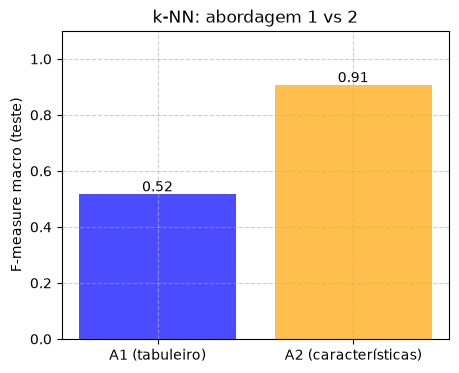

In [17]:
plt.figure(figsize=(5, 4))
plt.bar(tabela["abordagem"], tabela["f1_macro"], color=["blue", "orange"], alpha=0.7)
for i, v in enumerate(tabela["f1_macro"]):
    plt.text(i, v + 0.01, f"{v:.2f}", ha="center")
plt.ylim(0, 1.1)
plt.ylabel("F-measure macro (teste)")
plt.title("k-NN: abordagem 1 vs 2")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

In [18]:
tabela[["abordagem", "acuracia", "f1_macro", "gap_treino_val", "tempo_treino_ms", "tempo_pred_ms"]].round(3)

,abordagem,acuracia,f1_macro,gap_treino_val,tempo_treino_ms,tempo_pred_ms
0,A1 (tabuleiro),0.656,0.517,0.177,0.74,1.001
1,A2 (características),0.882,0.907,0.061,1.37,1.106


## 10. Exportação do modelo para a interface

Escolhemos a representação de entrada pelo **F1 macro de validação** e, em empate,
pela acurácia de validação. Se ambos forem iguais, mantemos a primeira abordagem
na ordem do experimento. O teste não participa dessa escolha.

Salvamos o modelo já ajustado somente no treino, suas configurações, os resultados
da busca e as previsões de teste da abordagem escolhida. Quando o modelo possui
padronização, o `Pipeline` preserva o padronizador ajustado no treino. A exportação
não realiza um novo ajuste.

Os metadados registram a versão do scikit-learn, as colunas de entrada e os hashes
dos CSVs utilizados. Assim, a interface carrega a mesma representação e o mesmo
modelo do experimento, sem treinar durante as partidas. Cada previsão pode ser
comparada ao registro de teste exportado.

O Codex auxiliou na inclusão desta etapa de exportação e na integração com a interface.


In [19]:
import hashlib
import json
import platform

import joblib
import sklearn

ab_escolhida = max(abordagens, key=lambda ab: melhor[ab]["chave"])
modelo_exportado = melhor[ab_escolhida]["modelo"]
PASTA_RESULTADOS = BASE / "knn" / "resultados"
PASTA_RESULTADOS.mkdir(parents=True, exist_ok=True)

# A escolha acima utiliza somente validação; estas previsões servem para auditoria.
d_exportado = dados[ab_escolhida]
previsoes_exportadas = modelo_exportado.predict(d_exportado["X_test"])
pd.DataFrame({
    "abordagem": ab_escolhida,
    "id_tabuleiro": d_exportado["ids_test"].to_numpy(),
    "estado_real": d_exportado["y_test"],
    "estado_previsto": previsoes_exportadas,
    "acertou": d_exportado["y_test"] == previsoes_exportadas,
}).to_csv(PASTA_RESULTADOS / "previsoes_teste.csv", index=False)
resultados.to_csv(PASTA_RESULTADOS / "busca_validacao.csv", index=False)

arquivos_entrada = [
    BASE / ab / f"{conjunto}.csv"
    for ab in abordagens
    for conjunto in ["treino", "validacao", "teste"]
]
resumo = {
    "algoritmo": "k-NN", "semente": SEED,
    "versoes": {"python": platform.python_version(), "scikit_learn": sklearn.__version__,
                "pandas": pd.__version__, "joblib": joblib.__version__},
    "classes": CLASSES,
    "criterio_selecao_configuracao": "F1 macro de validação; acurácia; primeira configuração da grade",
    "criterio_selecao_abordagem": "F1 macro de validação; acurácia; primeira abordagem",
    "configuracoes_testadas": len(resultados),
    "abordagem_escolhida_pela_validacao": ab_escolhida,
    "configuracoes_selecionadas": {ab: info["params"] for ab, info in melhor.items()},
    "metricas_validacao": {
        ab: {"f1_macro": info["chave"][0], "acuracia": info["chave"][1]}
        for ab, info in melhor.items()
    },
    "features_modelo_exportado": list(d_exportado["X_train"].columns),
    "ordem_classes_modelo": list(map(str, modelo_exportado.classes_)),
    "metricas_teste_modelo_exportado": metricas(d_exportado["y_test"], previsoes_exportadas),
    "csvs_entrada_sha256": {
        str(caminho.relative_to(RAIZ)): hashlib.sha256(caminho.read_bytes()).hexdigest()
        for caminho in arquivos_entrada
    },
}
(PASTA_RESULTADOS / "resumo_experimento.json").write_text(
    json.dumps(resumo, ensure_ascii=False, indent=2) + "\n", encoding="utf-8",
)
joblib.dump(modelo_exportado, PASTA_RESULTADOS / "modelo_knn.joblib", compress=3)

print("Abordagem exportada:", abordagens[ab_escolhida])
print("Configuração:", melhor[ab_escolhida]["params"])
print("F1 macro de validação:", round(melhor[ab_escolhida]["chave"][0], 6))
print("Arquivos salvos em:", PASTA_RESULTADOS.relative_to(RAIZ))


Abordagem exportada: A2 (características)
Configuração: {'k': 3, 'metrica': 'manhattan', 'pesos': 'uniform'}
F1 macro de validação: 0.88613
Arquivos salvos em: dataset/processado/knn/resultados
